# One-Dimensional Bose-Einstein Condensate

In this notebook we will compute the ground state of a one-dimensional Bose-Einstein condensate (BEC). Once the ground-state wave function is obtained, we can calculate the particle density,

$$
\rho(x)=|\psi(x)|^2.
$$

The ground state is described by the time-independent Gross-Pitaevskii equation,

$$
\mu \psi(x)=

-\frac{1}{2}\frac{d^2\psi}{dx^2}
+V(x)\psi
+g|\psi(x)|^2\psi
.
$$

where

- $\mu$ is the chemical potential,
- $g$ is the interaction strength, and
- $V(x)$ is the external trapping potential.

Throughout this notebook we consider a trap,

$$
V(x)=x^4-2x^2.
$$

The chemical potential is defined as

$$
\mu=\frac{\partial E}{\partial N},
$$

which represents the energy required to add one more particle to the condensate.

To obtain the ground state numerically, we evolve the Gross-Pitaevskii equation in **imaginary time**,

$$
t\rightarrow -i\tau,
$$

so that the wave function evolves according to

$$
\psi(\tau+\Delta\tau)
=
e^{-\Delta\tau\hat H/\hbar}\psi(\tau).
$$

Writing the Hamiltonian as

$$
\hat H=\hat T+\hat V,
$$

the second-order Split-Step approximation is

$$
e^{-\Delta\tau(\hat T+\hat V)}
\approx
e^{-\frac{\Delta\tau}{2}\hat V}
e^{-\Delta\tau\hat T}
e^{-\frac{\Delta\tau}{2}\hat V}.
$$

After each iteration, the wave function is normalized. Repeating this procedure removes the excited-state components, leaving only the ground state.

## Implementation

In [1]:
import numpy as np
from matplotlib import pyplot as plt

In [2]:
def create_grid(N=1024, x_min=-7, x_max=7):
    """
    Create the spatial grid and its corresponding Fourier-space grid
    used by the Split-Step method.
    """
    # Real Space Grid
    x = np.linspace(x_min, x_max, N)
    dx = x[1]-x[0]
    #Fourier Space Grid
    k = 2*np.pi * np.fft.fftfreq(N, d=dx)
    return x,dx,k

In [3]:
def potential(x):
    """
    Calculate potential
    """
    V = x**4-2*x**2
    return V

In [4]:
def normalize(psi,x):
    """
    Normalize the wave function so that its total
    probability is equal to one.
    """
    density = np.abs(psi)**2
    sqrt_norm = np.sqrt(np.trapezoid(density, x))
    return psi/sqrt_norm

In [5]:
def init_condition(x):
    """
    Generate an initial guess for the wave function
    used to start the imaginary-time evolution.
    """
    psi_init = np.exp(-x**2)
    psi_init = normalize(psi_init,x)
    return psi_init

In [6]:
def split_step(g, dtau=1e-3):
    """
    Compute the ground-state wave function by evolving
    the Gross-Pitaevskii equation in imaginary time
    using the Split-Step Fourier method.
    """
    x, dx, k = create_grid()
    V = potential(x)
    psi = init_condition(x)
    for i in range(50000):
        # First potential operator
        psi *= np.exp(- (1/2) * dtau * (V + g*np.abs(psi)**2))

        # Transform to Fourier space
        psi_fourier = np.fft.fft(psi)

        # Apply the kinetic operator
        psi_fourier *= np.exp(- (1/2) * dtau * k**2)

        # Transform back to real space
        psi = np.fft.ifft(psi_fourier)

        # Second potential operator
        psi *= np.exp(- (1/2) * dtau * (V + g*np.abs(psi)**2))

        # Normalize the wave function
        psi = normalize(psi, x)
    return psi

In [7]:
def plot_bec(x, psi, save=False, name='bec.png'):
    """
    Plot the particle density of the Bose-Einstein
    condensate.
    """
    fig, ax = plt.subplots(figsize=(7, 4))

    ax.plot(x, np.abs(psi)**2, lw=2)

    ax.set_xlabel(r"$x$")
    ax.set_ylabel(r"$|\psi(x)|^2$")

    # Nice style
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.tick_params(direction="out", length=5, width=1)
    ax.margins(x=0)

    plt.tight_layout()

    if save:
        plt.savefig(name, dpi=300, bbox_inches="tight")

    plt.show()

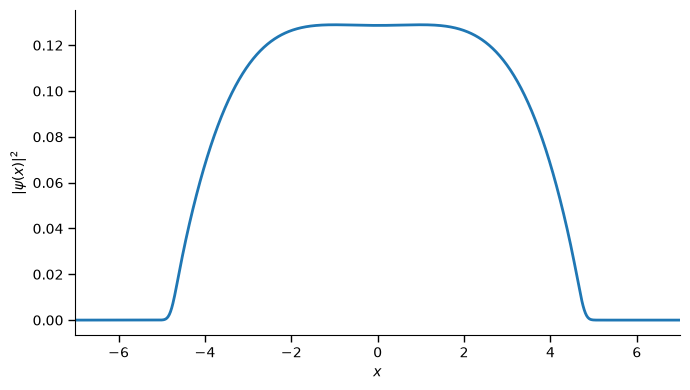

In [8]:
# Choose a value for g [0.1-10000]
g=5000
x,dx,k = create_grid()
psi = split_step(g=g)
plot_bec(x,psi)

## References

1. C. J. Pethick and H. Smith,
   *Bose-Einstein Condensation in Dilute Gases.*

2. L. P. Pitaevskii and S. Stringari,
   *Bose-Einstein Condensation.*

---
## Author
Nicolas Jimenez Coria